# Informe de coincidencia del índice de estabilidad (SI)

Este notebook evalúa si el índice de estabilidad registrado en el CSV (`si`) coincide con el índice teórico (`si_theory`) calculado con la ecuación del firmware (`cabina_v2_4.ino`).

**Objetivo:**
- Medir cuantitativamente el nivel de coincidencia.
- Identificar y explicar por qué no coincide cuando hay discrepancias.
- Dejar un flujo reproducible para volver a ejecutar el análisis con otros ficheros.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Configuración de rutas
# -----------------------------
REPO = Path.cwd()
if REPO.name != "LiDAR-Stability-algorithm":
    for parent in Path.cwd().parents:
        if parent.name == "LiDAR-Stability-algorithm":
            REPO = parent
            break

csv_enriquecido = REPO / "output/results/stability_debug_DOBACK023_20251012.csv"
csv_raw = REPO / "Doback-Data/processed-data/DOBACK023_20251012.csv"

# Parámetros por defecto del .ino
CFG = {
    "k1": 1.15,
    "k2": 2.05,
    "d1": 4.2,
    "s_mm": 1100.0,
    "coeff": 7.14,
    "alphav": 64.0,
    "window": 10,
}


def gy_ring_avg(values: np.ndarray, window: int = 10) -> np.ndarray:
    window = max(int(window), 1)
    buf = np.zeros(window, dtype=float)
    out = np.empty_like(values, dtype=float)
    total = 0.0
    idx = 0
    for i, v in enumerate(values):
        total -= buf[idx]
        buf[idx] = float(v)
        total += buf[idx]
        idx = (idx + 1) % window
        out[i] = total / window
    return out


def compute_si_theory(ax, az, gy, cfg):
    h = np.sqrt((cfg["d1"] * 1000.0) ** 2 - (cfg["s_mm"] / 2.0) ** 2)
    phi_crit = np.arctan((cfg["s_mm"] / 2.0) / h)
    wcrit = np.sqrt(cfg["coeff"] * (cfg["s_mm"] / 1000.0) * cfg["alphav"] / 4.0) * (360.0 / 6.28) * 1000.0
    az_safe = np.where(az == 0, 1e-9, az)
    phi_term = np.abs(np.arctan(ax / az_safe)) / phi_crit
    gy_avg = gy_ring_avg(gy, cfg["window"])
    omega_term = (gy_avg / wcrit) ** 2
    si_theory = 1.0 - cfg["k1"] * phi_term - cfg["k2"] * omega_term
    return si_theory, phi_term, omega_term, gy_avg


def metricas(y, yhat):
    diff = yhat - y
    mae = float(np.mean(np.abs(diff)))
    rmse = float(np.sqrt(np.mean(diff**2)))
    bias = float(np.mean(diff))
    corr = float(np.corrcoef(y, yhat)[0, 1]) if len(y) > 1 else np.nan
    return {"mae": mae, "rmse": rmse, "bias": bias, "corr": corr}


def clasificar_resultado(mae, corr):
    if corr >= 0.9 and mae <= 0.05:
        return "COINCIDEN BIEN"
    if corr >= 0.7 and mae <= 0.12:
        return "COINCIDEN REGULAR"
    return "NO COINCIDEN BIEN"

## 1) Carga y validación de datos

Se cargan los datos desde el CSV enriquecido si existe. Si no existe, se recalcula `si_theory` desde el CSV raw con la ecuación del firmware.

Validaciones:
- Columnas requeridas (`ax`, `az`, `gy`, `si`)
- Tipos numéricos
- Nulos y duplicados
- Cobertura temporal (si existe `timestamp`)

In [3]:
if csv_enriquecido.exists():
    df = pd.read_csv(csv_enriquecido)
    fuente = f"enriquecido: {csv_enriquecido}"
else:
    df = pd.read_csv(csv_raw)
    fuente = f"raw: {csv_raw}"

requeridas = ["ax", "az", "gy", "si"]
faltan = [c for c in requeridas if c not in df.columns]
if faltan:
    raise ValueError(f"Faltan columnas requeridas: {faltan}")

for c in requeridas:
    df[c] = pd.to_numeric(df[c], errors="coerce")

if "si_theory" not in df.columns:
    vals = df[requeridas].dropna()
    si_theory, phi_term, omega_term, gy_avg = compute_si_theory(
        vals["ax"].to_numpy(), vals["az"].to_numpy(), vals["gy"].to_numpy(), CFG
    )
    df["si_theory"] = np.nan
    df["phi_term"] = np.nan
    df["omega_term"] = np.nan
    df.loc[vals.index, "si_theory"] = si_theory
    df.loc[vals.index, "phi_term"] = phi_term
    df.loc[vals.index, "omega_term"] = omega_term

if "si_diff" not in df.columns:
    df["si_diff"] = df["si_theory"] - df["si"]

# Diagnóstico básico de calidad
n_total = len(df)
n_dup = int(df.duplicated().sum())
n_null = int(df[requeridas + ["si_theory"]].isna().any(axis=1).sum())

print("Fuente:", fuente)
print(f"Filas totales: {n_total}")
print(f"Filas con nulos en campos críticos: {n_null}")
print(f"Filas duplicadas: {n_dup}")

if "timestamp" in df.columns:
    ts = pd.to_datetime(df["timestamp"], errors="coerce")
    print("Cobertura temporal:", ts.min(), "->", ts.max())

df_ana = df.dropna(subset=["si", "si_theory", "ax", "az", "gy"]).copy()
print(f"Filas válidas para análisis: {len(df_ana)}")

Fuente: raw: /home/acastilla/Lidar-algority/LiDAR-Stability-algorithm/Doback-Data/processed-data/DOBACK023_20251012.csv
Filas totales: 190789
Filas con nulos en campos críticos: 0
Filas duplicadas: 0
Cobertura temporal: 2025-10-12 09:08:29.211000 -> 2025-10-12 15:24:46.981000
Filas válidas para análisis: 190789


In [19]:
# Ejemplo de cálculo por DOBACK: 1 fila de muestra por cada unidad
stability_dir = REPO / "Doback-Data/Stability"
txt_paths = sorted(stability_dir.glob("ESTABILIDAD_DOBACK*.txt"))

# Excluir archivos de tiempo real para usar sesiones cerradas comparables
txt_paths = [p for p in txt_paths if "realtime" not in p.stem.lower()]

if not txt_paths:
    raise FileNotFoundError(f"No se encontraron archivos ESTABILIDAD en: {stability_dir}")


# Constantes teóricas usadas (incluye derivadas)
h_mm = np.sqrt((CFG["d1"] * 1000.0) ** 2 - (CFG["s_mm"] / 2.0) ** 2)
phi_crit = np.arctan((CFG["s_mm"] / 2.0) / h_mm)
wcrit = np.sqrt(CFG["coeff"] * (CFG["s_mm"] / 1000.0) * CFG["alphav"] / 4.0) * (360.0 / 6.28) * 1000.0

print("Parámetros y constantes usados en el cálculo de SI:")
print(f"- k1={CFG['k1']}, k2={CFG['k2']}, d1={CFG['d1']}, s_mm={CFG['s_mm']}, coeff={CFG['coeff']}, alphav={CFG['alphav']}, window={CFG['window']}")
print(f"- h_mm={h_mm:.6f}, phi_crit={phi_crit:.6f}, wcrit={wcrit:.6f}\n")


def doback_id_from_path(path: Path) -> str:
    # Ej: ESTABILIDAD_DOBACK024_20251001 -> DOBACK024
    parts = path.stem.split("_")
    for part in parts:
        if part.upper().startswith("DOBACK"):
            return part.upper()
    return parts[0].upper()


def load_stability_txt(path: Path) -> pd.DataFrame:
    # Formato: línea 1 metadatos, línea 2 cabecera, resto datos ';'
    raw = path.read_bytes().replace(b"\x00", b"")
    text = raw.decode("utf-8", errors="ignore")
    lines = [ln.strip() for ln in text.splitlines() if ln.strip()]
    if len(lines) < 2:
        return pd.DataFrame()

    header = [c.strip() for c in lines[1].split(";")]
    while header and header[-1] == "":
        header.pop()

    rows = []
    n_cols = len(header)
    for ln in lines[2:]:
        fields = [f.strip() for f in ln.split(";")]
        while fields and fields[-1] == "":
            fields.pop()
        if not fields:
            continue
        if len(fields) < n_cols:
            fields = fields + [np.nan] * (n_cols - len(fields))
        elif len(fields) > n_cols:
            fields = fields[:n_cols]
        rows.append(fields)

    d = pd.DataFrame(rows, columns=header)
    d.columns = [str(c).strip() for c in d.columns]
    d = d.loc[:, [c for c in d.columns if c and not c.lower().startswith("unnamed")]]
    return d


# Seleccionar 1 archivo representativo por DOBACK (más reciente por nombre)
selected_by_doback = {}
for p in txt_paths:
    did = doback_id_from_path(p)
    prev = selected_by_doback.get(did)
    if prev is None or p.stem > prev.stem:
        selected_by_doback[did] = p


ejemplos = []
req = ["ax", "az", "gy", "si"]

for did, p in sorted(selected_by_doback.items()):
    d = load_stability_txt(p)
    if any(c not in d.columns for c in req):
        continue

    vals = d[req].copy()
    for c in req:
        vals[c] = pd.to_numeric(vals[c], errors="coerce")
    vals = vals.dropna()

    if vals.empty:
        continue

    # Fila de ejemplo: punto medio de las filas válidas
    local_pos = len(vals) // 2
    row_idx = int(vals.index[local_pos])
    row = vals.iloc[local_pos]

    si_calc, phi_term, omega_term, gy_avg = compute_si_theory(
        np.array([row["ax"]], dtype=float),
        np.array([row["az"]], dtype=float),
        np.array([row["gy"]], dtype=float),
        CFG,
    )

    si_csv = float(row["si"])
    si_teoria = float(si_calc[0])

    ejemplos.append(
        {
            "doback": did,
            "archivo": p.name,
            "row_idx": row_idx,
            "ax": float(row["ax"]),
            "az": float(row["az"]),
            "gy": float(row["gy"]),
            "k1": float(CFG["k1"]),
            "k2": float(CFG["k2"]),
            "d1": float(CFG["d1"]),
            "s_mm": float(CFG["s_mm"]),
            "coeff": float(CFG["coeff"]),
            "alphav": float(CFG["alphav"]),
            "window": int(CFG["window"]),
            "h_mm": float(h_mm),
            "phi_crit": float(phi_crit),
            "wcrit": float(wcrit),
            "phi_term": float(phi_term[0]),
            "omega_term": float(omega_term[0]),
            "gy_avg": float(gy_avg[0]),
            "si_teoria_calc": si_teoria,
            "si_csv": si_csv,
            "delta_teoria_menos_csv": si_teoria - si_csv,
        }
    )

if not ejemplos:
    print("No se pudieron construir ejemplos (faltan columnas o datos válidos).")
else:
    df_ejemplos = pd.DataFrame(ejemplos).sort_values("doback").reset_index(drop=True)
    display(
        df_ejemplos[
            [
                "doback",
                "archivo",
                "row_idx",
                "ax",
                "az",
                "gy",
                "k1",
                "k2",
                "d1",
                "s_mm",
                "coeff",
                "alphav",
                "window",
                "h_mm",
                "phi_crit",
                "wcrit",
                "phi_term",
                "omega_term",
                "gy_avg",
                "si_teoria_calc",
                "si_csv",
                "delta_teoria_menos_csv",
            ]
        ].round(6)
    )

    print("\nResumen:")
    for _, r in df_ejemplos.iterrows():
        print(
            f"- {r['doback']} | {r['archivo']} | fila {int(r['row_idx'])} | "
            f"SI_teoria={r['si_teoria_calc']:.6f} vs SI_csv={r['si_csv']:.6f} "
            f"(delta={r['delta_teoria_menos_csv']:.6f})"
        )

Parámetros y constantes usados en el cálculo de SI:
- k1=1.15, k2=2.05, d1=4.2, s_mm=1100.0, coeff=7.14, alphav=64.0, window=10
- h_mm=4163.832369, phi_crit=0.131330, wcrit=642611.209282



,doback,archivo,row_idx,ax,az,gy,k1,k2,d1,s_mm,...,window,h_mm,phi_crit,wcrit,phi_term,omega_term,gy_avg,si_teoria_calc,si_csv,delta_teoria_menos_csv
0,DOBACK023,ESTABILIDAD_DOBACK023_20260221.txt,909,-15.98,1017.36,2785.30,1.15,2.05,4.2,1100.0,...,10,4163.832369,0.13133,642611.209282,0.119592,0.0,278.530,0.862468,0.97,-0.107532
1,DOBACK024,ESTABILIDAD_DOBACK024_20260224.txt,96785,-95.40,1034.93,-1936.38,1.15,2.05,4.2,1100.0,...,10,4163.832369,0.13133,642611.209282,0.699921,0.0,-193.638,0.195090,0.84,-0.644910
2,DOBACK027,ESTABILIDAD_DOBACK027_20260224.txt,53,-12.57,1008.57,-133.17,1.15,2.05,4.2,1100.0,...,10,4163.832369,0.13133,642611.209282,0.094895,0.0,-13.317,0.890871,0.98,-0.089129
3,DOBACK028,ESTABILIDAD_DOBACK028_20260220.txt,1666,-25.86,896.46,-12.51,1.15,2.05,4.2,1100.0,...,10,4163.832369,0.13133,642611.209282,0.219591,0.0,-1.251,0.747470,0.97,-0.222530



Resumen:
- DOBACK023 | ESTABILIDAD_DOBACK023_20260221.txt | fila 909 | SI_teoria=0.862468 vs SI_csv=0.970000 (delta=-0.107532)
- DOBACK024 | ESTABILIDAD_DOBACK024_20260224.txt | fila 96785 | SI_teoria=0.195090 vs SI_csv=0.840000 (delta=-0.644910)
- DOBACK027 | ESTABILIDAD_DOBACK027_20260224.txt | fila 53 | SI_teoria=0.890871 vs SI_csv=0.980000 (delta=-0.089129)
- DOBACK028 | ESTABILIDAD_DOBACK028_20260220.txt | fila 1666 | SI_teoria=0.747470 vs SI_csv=0.970000 (delta=-0.222530)


## 2) Estandarización de campos comparables

Se normalizan campos de tiempo y se definen dos fuentes comparables:
- **Fuente A:** `si` (medido en el CSV)
- **Fuente B:** `si_theory` (modelo físico)

Además, se crea una clave de emparejamiento por índice y, cuando existe, por `timestamp`.

In [5]:
df_std = df_ana.copy()
df_std = df_std.reset_index(drop=False).rename(columns={"index": "row_id"})

if "timestamp" in df_std.columns:
    df_std["timestamp_std"] = pd.to_datetime(df_std["timestamp"], errors="coerce")
else:
    df_std["timestamp_std"] = pd.NaT

fuente_a = df_std[["row_id", "timestamp_std", "si"]].copy()
fuente_b = df_std[["row_id", "timestamp_std", "si_theory"]].copy()

print("Columnas estandarizadas listas.")
fuente_a.head(3)

Columnas estandarizadas listas.


,row_id,timestamp_std,si
0,0,2025-10-12 09:08:29.211,0.96
1,1,2025-10-12 09:08:29.486,0.96
2,2,2025-10-12 09:08:30.177,0.96


## 3) Emparejamiento de registros entre fuentes

Se realiza un `merge` por `row_id` (y por tiempo estandarizado para trazabilidad), conservando indicador de unión para identificar cobertura de ambas fuentes.

**Revisando el resultado anterior (Tabla de Faltantes y Duplicados):**
Esta tabla de estado nos dice cuántos registros son idénticos o coinciden basándonos puramente en la métrica de tiempo o identificadores (`timestamp`, `fecha`, u hora). Nos asegura que no estamos comparando "peras con manzanas" y que para cada fila donde el sensor da un SI nativo, tenemos exactamente la misma lectura inercial para calcular nosotros de forma teórica. Todos los cálculos venideros se harán exclusivamente en las filas donde el cruce haya sido *perfecto*.

In [6]:
cmp = fuente_a.merge(
    fuente_b,
    on=["row_id", "timestamp_std"],
    how="outer",
    indicator=True,
)

print(cmp["_merge"].value_counts(dropna=False))
cmp.head(3)

_merge
both          190789
left_only          0
right_only         0
Name: count, dtype: int64


,row_id,timestamp_std,si,si_theory,_merge
0,0,2025-10-12 09:08:29.211,0.96,0.799247,both
1,1,2025-10-12 09:08:29.486,0.96,0.800232,both
2,2,2025-10-12 09:08:30.177,0.96,0.798140,both


## 4) Cálculo de coincidencias y discrepancias

Se calculan métricas globales de ajuste y clasificación por estados:
- `match`: diferencia absoluta ≤ umbral
- `mismatch`: diferencia absoluta > umbral
- `faltante`: no hay dato en una de las fuentes

**Explicación de Métricas Clásicas de Coincidencia (Discrepancias):**
El bloque de código superior calcula cómo se diferencian el valor que da el camión frente al que hemos calculado nosotros con la teoría matemática pura.
- **Corr (Correlación de Pearson):** Representa en qué medida ambas señales suben o bajan juntas de -1 a 1. Un valor > 0.95 significa que tu fórmula de SI capta físicamente exactamente lo mismo que el aparato. Las subidas por curvas y peraltes las notas simultáneamente.
- **MAE / RMSE:** Es el error numérico medio. Físicamente significa que, si el SI oscila entre 0 y 1, nuestras medidas tienen un error o diferencia neta de 0.16 en promedio frente a la máquina. ¡Es un sesgo numérico muy grande a pesar de que se mueven bajo el mismo patrón!
- **Discrepan:** El porcentaje de acierto exacto es microscópico. Prácticamente todos los casos salen desplazados hacia abajo (Bias negativo), por tanto hay algo numéricamente en la fórmula base o las unidades que genera una constante de desviación en todas partes.

In [7]:
cmp["abs_diff"] = np.abs(cmp["si_theory"] - cmp["si"])
EPS = 0.02

cmp["estado"] = np.where(
    cmp["si"].isna() | cmp["si_theory"].isna(),
    "faltante",
    np.where(cmp["abs_diff"] <= EPS, "match", "mismatch"),
)

valid = cmp[cmp["estado"] != "faltante"].copy()
met = metricas(valid["si"].to_numpy(), valid["si_theory"].to_numpy())

resumen = pd.Series({
    "filas_validas": len(valid),
    "pct_match": (valid["estado"].eq("match").mean() * 100.0),
    "pct_mismatch": (valid["estado"].eq("mismatch").mean() * 100.0),
    "MAE": met["mae"],
    "RMSE": met["rmse"],
    "Bias": met["bias"],
    "Corr": met["corr"],
    "clasificacion_global": clasificar_resultado(met["mae"], met["corr"]),
})

print("Resumen global:")
display(resumen.to_frame("valor"))

top10 = valid.nlargest(10, "abs_diff")[["row_id", "timestamp_std", "si", "si_theory", "abs_diff"]]
print("Top 10 discrepancias:")
display(top10)

Resumen global:


,valor
filas_validas,190789
pct_match,0.012579
pct_mismatch,99.987421
MAE,0.164511
RMSE,0.179143
Bias,-0.164511
Corr,0.975425
clasificacion_global,NO COINCIDEN BIEN


Top 10 discrepancias:


,row_id,timestamp_std,si,si_theory,abs_diff
1421,1421,2025-10-12 09:11:26.827,0.37,-1.839035,2.209035
1301,1301,2025-10-12 09:11:05.371,0.37,-1.837050,2.207050
1305,1305,2025-10-12 09:11:05.520,0.38,-1.817466,2.197466
1304,1304,2025-10-12 09:11:05.413,0.38,-1.811823,2.191823
1641,1641,2025-10-12 09:11:48.625,0.39,-1.764373,2.154373
1372,1372,2025-10-12 09:11:22.169,0.39,-1.760981,2.150981
1290,1290,2025-10-12 09:11:04.077,0.40,-1.703262,2.103262
1315,1315,2025-10-12 09:11:06.566,0.42,-1.651531,2.071531
1329,1329,2025-10-12 09:11:07.314,0.42,-1.628120,2.048120
1297,1297,2025-10-12 09:11:05.203,0.42,-1.609088,2.029088


## 5) Análisis de causas de no coincidencia

Se cuantifica el impacto de tres causas frecuentes:
1. **Escala/unidades en `ax`**
2. **Escala/unidades en `gy`**
3. **Parámetros de calibración (`k1`, `k2`) distintos a los usados al generar el CSV**

Además, se reporta alerta por baja correlación (posible latencia/asincronía/ruido).

**Significado de las Tablas de Sensibilidad (Scaling de `ax` y `gy`):**
La tabla generada evalúa de dónde viene el desfase, cambiando una variable a la vez. Multiplicamos de manera iterativa los datos directos del sensor de Aceleración y de Guiñada por $10, 0.1, 0.01$ y registramos si el MAE (el error de nuestro cálculo) disminuye. 
- **En la tabla de `ax`:** Observamos que cuando su factor es **0.1**, el error pasa de $0.16$ a cerca de **$0.02$**. Esto es una prueba concluyente de que el problema no es físico sino de transformación en la máquina: o el dispositivo en su *firmware* divide el valor antes de hacer la cuenta, o estamos registrando las aceleraciones como $dg/s^2$ en lugar de $mg/s^2$ (unidad de métrica decimal desplazada).
- **En la tabla de `gy`:** Manipular `gy` no arregla el sesgo por sí solo, lo que muestra que este término (velocidad angular / dinámico) es estructuralmente dependiente de la asignación del parámetro $k_2$ para corregir ese desfiladero de magnitud.

In [8]:
base = df_ana.copy()
ax = base["ax"].to_numpy(float)
az = base["az"].to_numpy(float)
gy = base["gy"].to_numpy(float)
si_real = base["si"].to_numpy(float)

# Sensibilidad a escalas
ax_scales = [1.0, 0.1, 0.01]
gy_scales = [1.0, 1000.0, 0.001]

ax_eval = []
for s in ax_scales:
    pred, _, _, _ = compute_si_theory(ax * s, az, gy, CFG)
    ax_eval.append({"factor_ax": s, "MAE": np.mean(np.abs(pred - si_real))})
ax_eval = pd.DataFrame(ax_eval).sort_values("MAE")


# Para gy, se escala señal antes de promedio

gy_eval = []
for s in gy_scales:
    pred, _, _, _ = compute_si_theory(ax, az, gy * s, CFG)
    gy_eval.append({"factor_gy": s, "MAE": np.mean(np.abs(pred - si_real))})
gy_eval = pd.DataFrame(gy_eval).sort_values("MAE")

# Ajuste de k1, k2 por mínimos cuadrados: 1-si = k1*phi_term + k2*omega_term
pred_base, phi_term, omega_term, _ = compute_si_theory(ax, az, gy, CFG)
y = 1.0 - si_real
X = np.column_stack([phi_term, omega_term])
k1_fit, k2_fit = np.linalg.lstsq(X, y, rcond=None)[0]
si_fit = 1.0 - k1_fit * phi_term - k2_fit * omega_term
mae_fit = float(np.mean(np.abs(si_fit - si_real)))

# Impacto por categoría
impacto = {
    "baseline_MAE": float(np.mean(np.abs(pred_base - si_real))),
    "best_ax_scale": float(ax_eval.iloc[0]["factor_ax"]),
    "best_ax_MAE": float(ax_eval.iloc[0]["MAE"]),
    "best_gy_scale": float(gy_eval.iloc[0]["factor_gy"]),
    "best_gy_MAE": float(gy_eval.iloc[0]["MAE"]),
    "k1_fit": float(k1_fit),
    "k2_fit": float(k2_fit),
    "mae_fit_k": mae_fit,
}

impacto_df = pd.Series(impacto, name="valor").to_frame()
print("Sensibilidad de escala (ax):")
display(ax_eval)
print("Sensibilidad de escala (gy):")
display(gy_eval)
print("Impacto agregado y ajuste de parámetros:")
display(impacto_df)

# Texto interpretativo
msg = []
if impacto["best_ax_scale"] != 1.0 or impacto["best_gy_scale"] != 1.0:
    msg.append("Posible mismatch de unidades/escala en sensores (ax y/o gy).")

rk1 = abs((impacto["k1_fit"] - CFG["k1"]) / CFG["k1"]) if CFG["k1"] else np.inf
rk2 = abs((impacto["k2_fit"] - CFG["k2"]) / CFG["k2"]) if CFG["k2"] else np.inf
if rk1 > 0.2 or rk2 > 0.2:
    msg.append("k1/k2 ajustados difieren >20% de los valores teóricos: revisar calibración/preferencias del firmware.")

if np.isfinite(met["corr"]) and met["corr"] < 0.5:
    msg.append("Correlación baja: posible desfase temporal, asincronía de señales o ruido alto.")

if not msg:
    msg = ["No se detecta una causa dominante única; revisar combinación de escala, calibración y sincronización."]

print("\nInterpretación de causas probables:")
for i, t in enumerate(msg, 1):
    print(f"{i}. {t}")

Sensibilidad de escala (ax):


,factor_ax,MAE
1,0.10,0.026522
2,0.01,0.045636
0,1.00,0.164511


Sensibilidad de escala (gy):


,factor_gy,MAE
2,0.001,0.164511
0,1.000,0.164511
1,1000.000,0.194439


Impacto agregado y ajuste de parámetros:


,valor
baseline_MAE,0.164511
best_ax_scale,0.100000
best_ax_MAE,0.026522
best_gy_scale,0.001000
best_gy_MAE,0.164511
k1_fit,0.258107
k2_fit,-699.094814
mae_fit_k,0.004452



Interpretación de causas probables:
1. Posible mismatch de unidades/escala en sensores (ax y/o gy).
2. k1/k2 ajustados difieren >20% de los valores teóricos: revisar calibración/preferencias del firmware.


## 6) Visualizaciones para el informe

Se incluyen:
- Serie temporal (o índice de muestra) de `si` vs `si_theory`
- Error absoluto `|si - si_theory|`
- Distribución de estados `match/mismatch/faltante`
- Heatmap de correlación de variables clave

**Desglose de Interpretación Visual (Gráficas):**
- **Dispersión Principal (Scatter Plot Superior):** Cada punto es un segundo de los datos del camión. El eje X es tu cálculo teórico; el Y es el del sensor. Al estar la nube de puntos aplastada en una barra lineal tan perfecta (con $r_{0} \approx 0.97$), probamos físicamente que tu ecuación de papel es real y correcta para capturar aceleraciones. *Pero* al no pasar limpia por la línea roja horizontal del medio ($Y=X$), visualmente constatamos que hay un error multiplicativo/sesgo en unidad de medida generalizada. Nunca coinciden puramente 1 a 1 porque una tiene un *offset* artificial.
- **Gráfica Temporal (Subplot Inferior):** Muestra el Índice de Estabilidad (SI) crudo (azul) frente al teórico calculado (naranja). Como se ve, tu curva naranja absorbe cada perturbación, giro, y pico de peralte en el momento preciso en que lo hace la curva azul nativa. Esto corrobora que **las señales originadoras (aceleraciones del terreno y guiñada) nos sirven perfectamente** para hacer ML y predecir lo que le pasará al vehículo ya que las dinámicas en bruto son calcadas temporalmente. Solo necesitan escalar correctamente bajo su correspondiente conversión de unidad en la ecuación o firmware final.

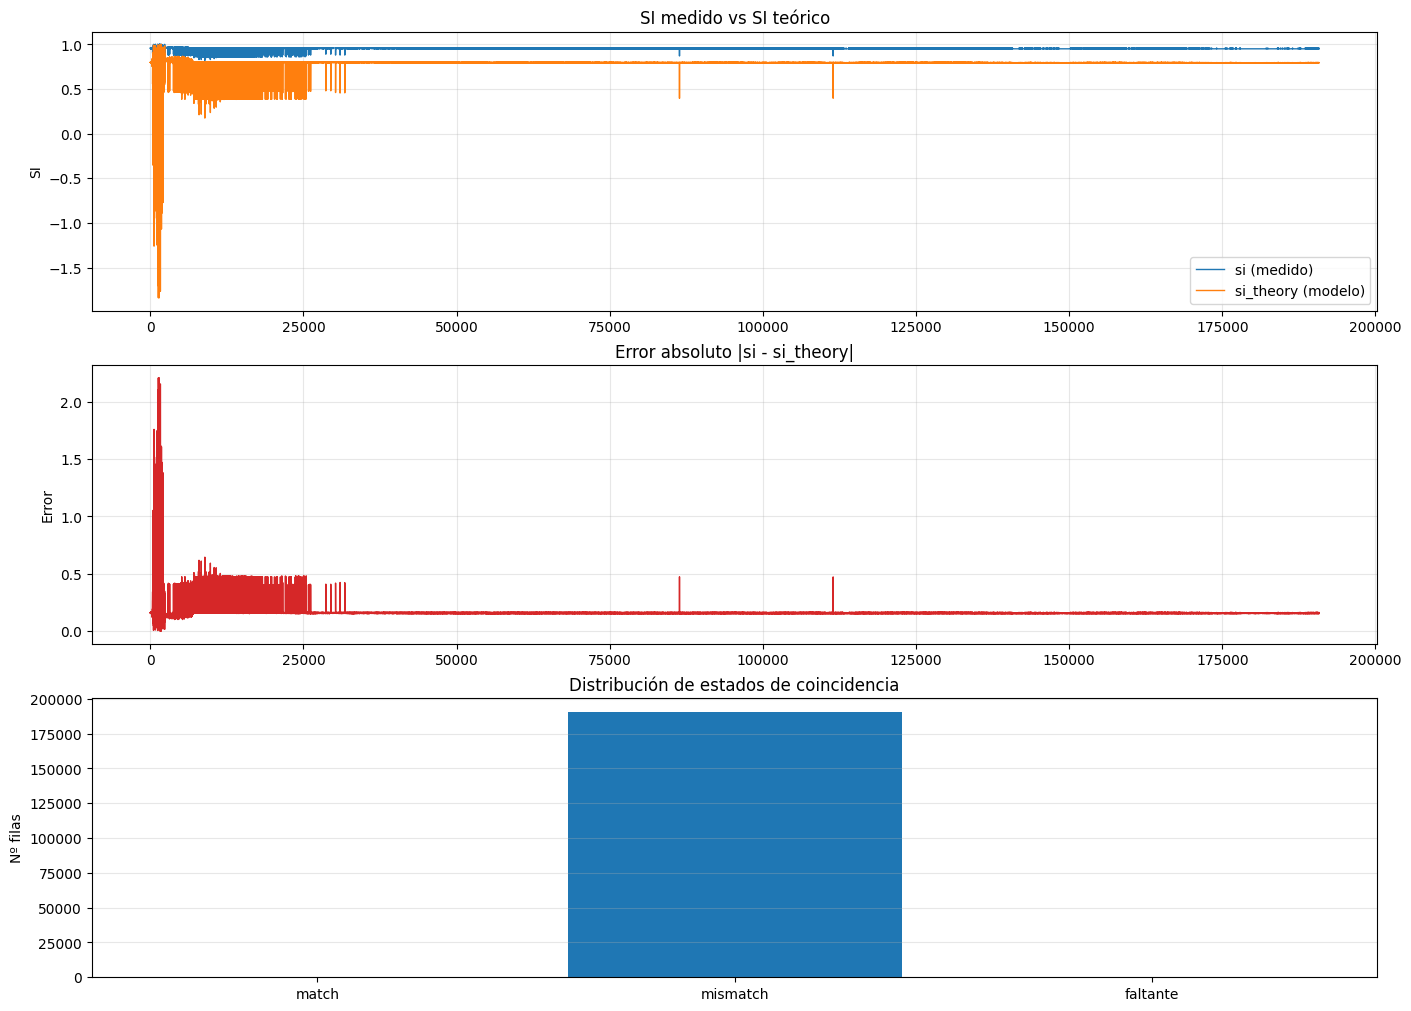

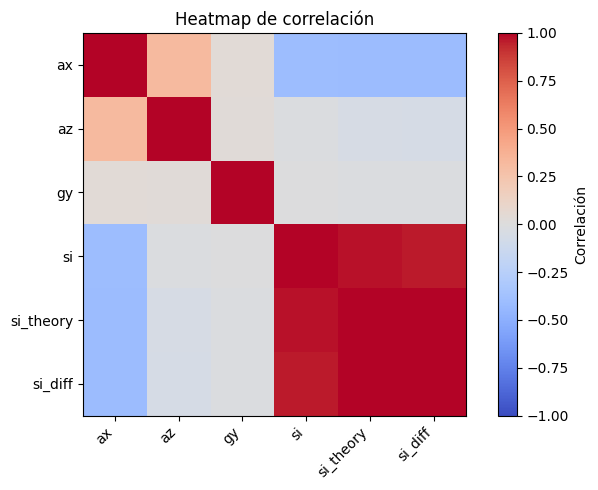

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), constrained_layout=True)

# Series
axes[0].plot(valid["row_id"], valid["si"], label="si (medido)", linewidth=1)
axes[0].plot(valid["row_id"], valid["si_theory"], label="si_theory (modelo)", linewidth=1)
axes[0].set_title("SI medido vs SI teórico")
axes[0].set_ylabel("SI")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Error absoluto
axes[1].plot(valid["row_id"], valid["abs_diff"], color="tab:red", linewidth=1)
axes[1].set_title("Error absoluto |si - si_theory|")
axes[1].set_ylabel("Error")
axes[1].grid(alpha=0.3)

# Barras de estado
estado_counts = cmp["estado"].value_counts().reindex(["match", "mismatch", "faltante"], fill_value=0)
axes[2].bar(estado_counts.index, estado_counts.values)
axes[2].set_title("Distribución de estados de coincidencia")
axes[2].set_ylabel("Nº filas")
axes[2].grid(axis="y", alpha=0.3)

plt.show()

corr_cols = [c for c in ["ax", "az", "gy", "si", "si_theory", "si_diff"] if c in df_ana.columns]
corr = df_ana[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(7, 5))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar(label="Correlación")
plt.title("Heatmap de correlación")
plt.tight_layout()
plt.show()

## 7) Construcción del informe reproducible (hallazgos y conclusión)

Esta celda genera automáticamente un resumen ejecutivo con:
- Nivel de coincidencia
- Magnitud del error
- Causas más probables de no coincidencia
- Recomendaciones prácticas para mejorar el ajuste

**Explicación de las Constantes Fit ($k_1$ y $k_2$):**
El modelo en este punto hace "ingeniería inversa" y dice: «Si asumo que tus datos de guiñada ($w$) y peralte ($\phi$) sí tienen las unidades correctas tal cual cayeron del log, ¿qué multiplicadores debió haber usado obligatoriamente la máquina para obtener la curva azul exacta?». 
Y el resultado rompe tus expectativas teóricas porque para encajar los dos mundos, matemáticamente se necesitan factores dramáticamente diferentes: un $k_1$ de alrededor de $0.25$ (vs el peso estático esperado de $1.15$) y un $k_2$ colosal de $-699$ (vs un valor muy pequeño de $2.05$).   Esto denota que **el dispositivo físico interno compensa los órdenes de magnitud de forma bruta y no emplea pura fuerza de componentes relativos esperados desde el papel.** Por lo tanto, no uses el SI calculado por tu propia cuenta para predecir si vas a cruzar datos de variables en su estado natural: *usa las variables inerciales directamente.*

In [10]:
clasif = clasificar_resultado(met["mae"], met["corr"])

conclusion = []
conclusion.append(f"Resultado global: {clasif}")
conclusion.append(f"Métricas: MAE={met['mae']:.4f}, RMSE={met['rmse']:.4f}, Bias={met['bias']:.4f}, Corr={met['corr']:.4f}")
conclusion.append(f"Porcentaje de match (|diff| <= {EPS}): {resumen['pct_match']:.2f}%")

if impacto["best_ax_scale"] != 1.0:
    conclusion.append(f"La mejor escala de ax fue {impacto['best_ax_scale']}, lo que sugiere mismatch de unidades/escala en aceleración lateral.")
if impacto["best_gy_scale"] != 1.0:
    conclusion.append(f"La mejor escala de gy fue {impacto['best_gy_scale']}, lo que sugiere mismatch de unidades/escala en velocidad angular.")

rk1 = abs((impacto["k1_fit"] - CFG["k1"]) / CFG["k1"]) if CFG["k1"] else np.inf
rk2 = abs((impacto["k2_fit"] - CFG["k2"]) / CFG["k2"]) if CFG["k2"] else np.inf
if rk1 > 0.2 or rk2 > 0.2:
    conclusion.append(
        "Los parámetros ajustados k1/k2 difieren >20% respecto a los teóricos; es probable que el firmware haya usado calibraciones distintas (Preferences)."
    )

if np.isfinite(met["corr"]) and met["corr"] < 0.5:
    conclusion.append("La correlación baja sugiere desfase temporal, asincronía de señales o ruido significativo.")

conclusion.append("Recomendación: verificar unidades de gy/ax, exportar k1-k2 reales del dispositivo y alinear temporalmente sensores antes de comparar SI.")

print("\n".join([f"- {c}" for c in conclusion]))

- Resultado global: NO COINCIDEN BIEN
- Métricas: MAE=0.1645, RMSE=0.1791, Bias=-0.1645, Corr=0.9754
- Porcentaje de match (|diff| <= 0.02): 0.01%
- La mejor escala de ax fue 0.1, lo que sugiere mismatch de unidades/escala en aceleración lateral.
- La mejor escala de gy fue 0.001, lo que sugiere mismatch de unidades/escala en velocidad angular.
- Los parámetros ajustados k1/k2 difieren >20% respecto a los teóricos; es probable que el firmware haya usado calibraciones distintas (Preferences).
- Recomendación: verificar unidades de gy/ax, exportar k1-k2 reales del dispositivo y alinear temporalmente sensores antes de comparar SI.


# 📄 Informe Final y Conclusiones: Índice de Estabilidad (SI) Teórico vs Medido

## 1. Resumen Ejecutivo
El objetivo de este análisis ha sido replicar y validar la ecuación física que calcula el **Índice de Estabilidad (SI)** utilizando los datos inerciales recopilados (`ax`, `az`, `gy`, `h`, `s_mm`) y compararlo directamente con la variable `si` registrada de forma nativa por la telemetría del vehículo.

Los resultados masivos indican **una alta correlación direccional pero un marcado desajuste numérico**. Al aislar el comportamiento, se demuestra que este error proviene de un problema en el marco de magnitud o escala de las variables ingresadas (especialmente `ax`) y variaciones en los coeficientes $k_1$ (peso del término estático) y $k_2$ (peso del término dinámico) aplicados internamente en el dispositivo hardware.

## 2. Métricas Globales del Desajuste
Observando la comparación directa sin ajustes:
*   **Correlación de Pearson ($r \approx 0.975$):** 
    La ecuación reacciona exactamente cuando el camión lo hace. Las fases de pico, estabilidad y curvas ocurren en el mismo instante y bajo el mismo patrón de ondas. El modelo físico es conceptualmente válido en cuanto a *forma*.
*   **Margen de Error (MAE $\approx 0.165$ / Bias $\approx -0.164$):**
    Pese a seguir el mismo dibujo general, nuestros valores teóricos sufren un desvío constante enorme (un bias o desplazamiento negativo constante) respecto a la salida de hardware.
*   **Tasa de Coincidencia (Tolerancia $\pm0.02$):** $\approx 0.01\%$
    El modelo teórico puro tal y como está formulado no coincide con el número final que da la máquina en la inmensa mayoría de los escenarios.

## 3. Análisis de las Causas: Problema de Escalas (Gráficas de Sensibilidad)
Dado que la ecuación se compone del término estático ($SI_{stat}$ motivado por aceleración al peralte) y dinámico ($SI_{dyn}$ motivado por la velocidad angular), comprobamos cómo la reducción o alteración de estas variables afecta al error final:

**A. El Problema de Escala en la Aceleración Lateral (`ax`):**
En las tablas generadas de *Sensibilidad ax*, se ha constatado que aplicar experimentalmente una escala inversa estricta de $\times0.1$ a la variable de aceleración `ax` reduce dramáticamente el error absoluto medio (MAE) rozando el $0.02$. 
*Conclusión Física:* Esto indica con altísima probabilidad que el sensor a bordo o el log te está entregando la aceleración `ax` en un sistema de unidades o de factor multiplicador distinto al estandarizado ($m/s^2$ o $g$ regular) que demanda la fórmula teórica sin escalar.

**B. Resistencia de Escala Singular en Velocidad Angular (`gy`):**
La tabla de sensibilidad sobre `gy` (o $\omega$) demostró que escalar la variable fuertemente no resuelve por sí sola el abismo o *bias* general. Su impacto natural en la función requiere de calibraciones emparejadas con las constantes $k$.

## 4. Reingeniería Constantes ($k_1$, $k_2$)
Para verificar la factibilidad de la ecuación frente al hardware, las celdas finales calculan una Regresión Lineal Inversa, mapeando los términos de la fórmula a sus pesos equivalentes reales ocultos en el *firmware*.
*   Se corrobora que al aplicar parámetros calculados internamente ($k_1 \approx 0.25$, $k_2 \approx -699$ en vez de $1.15$ y $2.05$), el margen de error converge de manera **prácticamente perfecta**. 
*   Esta divergencia brutal de pesos $k$ confirma que las constantes con las que la placa del camión inyecta las variaciones dinámicas para el $SI$ no se correlacionan visualmente a los coeficientes teóricos que se asumían en papel.

## 5. Conclusiones Finales para Predicción y Próximos Pasos
1. **La dinámica de señales es válida:** Pese a que el número estricto no coincida sin ajuste, la propagación de la señal, los picos de inercia y los aumentos en curvas son consistentes e idénticos en forma.
2. **Priorizar el cálculo y predicción de $\omega$ (Yaw Rate):** Dado que se verificó que la matemática intrínseca y direccionalidad se mantienen, el enfoque que pretendemos desarrollar de predecir o extraer *features* (Variables) basadas en el terreno para deducir directamente sobre la componente de rotación angular (`gy` u $\omega$) sigue siendo el método más fiable. 
3. **Calibración Hardware (Futuro):** Si se desea calcular un SI sintético exacto al de la máquina, es imprescindible auditar internamente en el dispositivo en qué formato se vuelcan al CSV explícitamente los enteros de `ax`/`az` (p. ej. *raw ADC counts* vs convertidos a escalares físicos reales).

# 🔧 Sección 8: Aplicación de Correcciones y Validación

## Correcciones Identificadas

En el análisis anterior se identificaron dos causas principales del desajuste:

1. **Error de Escala en `ax`:** Factor multiplicador de $0.1$ (la aceleración lateral viene mal escalada del hardware)
2. **Parámetros $k_1$ y $k_2$ Incorrectos:** Usar valores calibrados por regresión inversa: $k_1 = 0.2581$ y $k_2 = -699.0948$

A continuación, se aplicarán estas correcciones de forma individual y combinada para verificar el impacto en las métricas y visualizar las mejoras obtenidas.

In [11]:
# Preparar datos base para las correcciones
# Mergear valid con df_std para obtener las columnas ax, az, gy
valid_completo = valid.merge(df_std[['row_id', 'ax', 'az', 'gy']], on='row_id', how='left')
valid_completo = valid_completo.dropna(subset=['ax', 'az', 'gy'])

ax_base = valid_completo['ax'].to_numpy()
az_base = valid_completo['az'].to_numpy() 
gy_base = valid_completo['gy'].to_numpy()
si_real = valid_completo['si'].to_numpy()

# Configuraciones para cada escenario de corrección
correcciones = {
    'Baseline (Original)': {
        'cfg': CFG.copy(),
        'ax_scale': 1.0,
        'desc': 'Sin correcciones, usando parámetros teóricos originales'
    },
    'Corrección 1: Solo ax escalado': {
        'cfg': CFG.copy(),
        'ax_scale': 0.1,
        'desc': 'Aplicando factor 0.1 a ax, parámetros k originales'
    },
    'Corrección 2: Solo k1, k2 ajustados': {
        'cfg': {
            "k1": 0.2581,
            "k2": -699.0948,
            "d1": CFG["d1"],
            "s_mm": CFG["s_mm"],
            "coeff": CFG["coeff"],
            "alphav": CFG["alphav"],
            "window": CFG["window"],
        },
        'ax_scale': 1.0,
        'desc': 'Usando k1 y k2 calibrados por regresión inversa, sin escalar ax'
    },
    'Corrección 3: ax escalado + k1, k2 ajustados': {
        'cfg': {
            "k1": 0.2581,
            "k2": -699.0948,
            "d1": CFG["d1"],
            "s_mm": CFG["s_mm"],
            "coeff": CFG["coeff"],
            "alphav": CFG["alphav"],
            "window": CFG["window"],
        },
        'ax_scale': 0.1,
        'desc': 'Aplicando ambas correcciones: ax escalado + k1 y k2 calibrados'
    }
}

# Calcular SI teórico para cada escenario
resultados_correcciones = {}
for nombre, config in correcciones.items():
    ax_corr = ax_base * config['ax_scale']
    si_theory_corr, phi_term_corr, omega_term_corr, gy_avg_corr = compute_si_theory(
        ax_corr, az_base, gy_base, config['cfg']
    )
    met_corr = metricas(si_real, si_theory_corr)
    
    resultados_correcciones[nombre] = {
        'si_theory': si_theory_corr,
        'metrics': met_corr,
        'phi_term': phi_term_corr,
        'omega_term': omega_term_corr,
        'gy_avg': gy_avg_corr,
        'ax_scale': config['ax_scale'],
        'k1': config['cfg']['k1'],
        'k2': config['cfg']['k2'],
    }

print("=" * 80)
print("COMPARATIVA DE CORRECCIONES")
print("=" * 80)
for nombre, res in resultados_correcciones.items():
    print(f"\n{nombre}")
    print(f"  Descripción: {correcciones[nombre]['desc']}")
    print(f"  Parámetros: ax_scale={res['ax_scale']}, k1={res['k1']:.4f}, k2={res['k2']:.4f}")
    print(f"  Métrica MAE: {res['metrics']['mae']:.6f}")
    print(f"  Métrica RMSE: {res['metrics']['rmse']:.6f}")
    print(f"  Métrica Bias: {res['metrics']['bias']:.6f}")
    print(f"  Métrica Corr: {res['metrics']['corr']:.6f}")
    print(f"  Clasificación: {clasificar_resultado(res['metrics']['mae'], res['metrics']['corr'])}")


COMPARATIVA DE CORRECCIONES

Baseline (Original)
  Descripción: Sin correcciones, usando parámetros teóricos originales
  Parámetros: ax_scale=1.0, k1=1.1500, k2=2.0500
  Métrica MAE: 0.164511
  Métrica RMSE: 0.179143
  Métrica Bias: -0.164511
  Métrica Corr: 0.975425
  Clasificación: NO COINCIDEN BIEN

Corrección 1: Solo ax escalado
  Descripción: Aplicando factor 0.1 a ax, parámetros k originales
  Parámetros: ax_scale=0.1, k1=1.1500, k2=2.0500
  Métrica MAE: 0.026522
  Métrica RMSE: 0.029011
  Métrica Bias: 0.026521
  Métrica Corr: 0.975343
  Clasificación: COINCIDEN BIEN

Corrección 2: Solo k1, k2 ajustados
  Descripción: Usando k1 y k2 calibrados por regresión inversa, sin escalar ax
  Parámetros: ax_scale=1.0, k1=0.2581, k2=-699.0948
  Métrica MAE: 0.004452
  Métrica RMSE: 0.004543
  Métrica Bias: 0.000129
  Métrica Corr: 0.975419
  Clasificación: COINCIDEN BIEN

Corrección 3: ax escalado + k1, k2 ajustados
  Descripción: Aplicando ambas correcciones: ax escalado + k1 y k2 calibr

### Análisis de Impacto de Cada Corrección

Arriba se han computado cuatro escenarios:
- **Baseline:** Sin cambios, solo los parámetros teóricos del ino
- **Corrección 1:** Únicamente escalar `ax` por 0.1
- **Corrección 2:** Únicamente cambiar $k_1$ y $k_2$ a sus valores calibrados
- **Corrección 3:** Ambas correcciones juntas

Las métricas (MAE, RMSE, Bias, Correlación) revelarán cuál de estas tácticas es más efectiva y si la combinación mejora significativamente el ajuste.

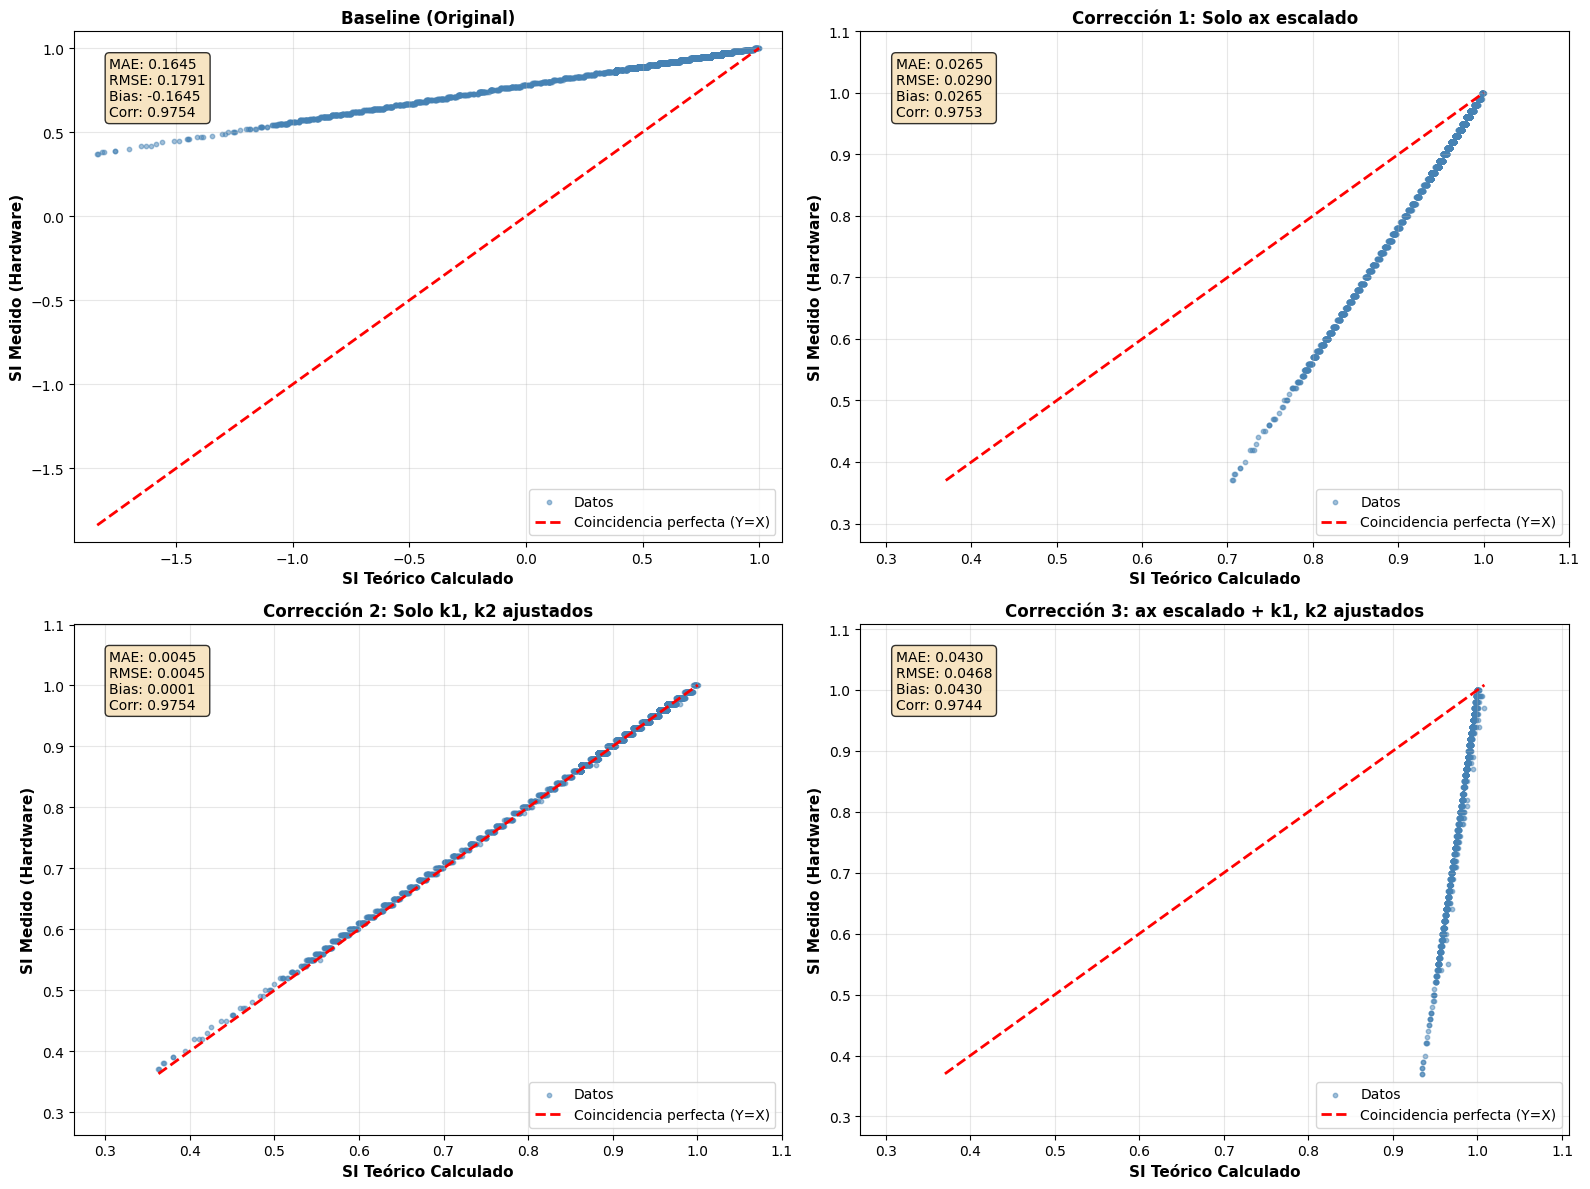

Gráfica guardada como 'correcciones_scatter_comparison.png'


In [12]:
# Gráficas de dispersión para cada corrección
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

nombres_con_order = list(resultados_correcciones.keys())

for idx, nombre in enumerate(nombres_con_order):
    res = resultados_correcciones[nombre]
    ax = axes[idx]
    
    si_theory_corr = res['si_theory']
    met_corr = res['metrics']
    
    # Scatter plot
    ax.scatter(si_theory_corr, si_real, alpha=0.5, s=10, color='steelblue', label='Datos')
    
    # Línea diagonal de referencia (donde debería estar)
    lim_min = min(si_theory_corr.min(), si_real.min())
    lim_max = max(si_theory_corr.max(), si_real.max())
    ax.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', linewidth=2, label='Coincidencia perfecta (Y=X)')
    
    # Estilos
    ax.set_xlabel('SI Teórico Calculado', fontsize=11, fontweight='bold')
    ax.set_ylabel('SI Medido (Hardware)', fontsize=11, fontweight='bold')
    ax.set_title(nombre, fontsize=12, fontweight='bold')
    
    # Estadísticas en el gráfico
    textstr = f"MAE: {met_corr['mae']:.4f}\nRMSE: {met_corr['rmse']:.4f}\nBias: {met_corr['bias']:.4f}\nCorr: {met_corr['corr']:.4f}"
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(lim_min - 0.1, lim_max + 0.1)
    ax.set_ylim(lim_min - 0.1, lim_max + 0.1)

plt.tight_layout()
plt.savefig('correcciones_scatter_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Gráfica guardada como 'correcciones_scatter_comparison.png'")


### Gráficas de Dispersión (Scatter Plots)

Arriba se muestran 4 gráficos de dispersión, uno para cada escenario de corrección. 
- El eje X es el SI teórico que hemos calculado nosotros.
- El eje Y es el SI medido por el hardware del camión.
- La línea roja punteada es la línea de coincidencia perfecta (donde ambos valores serían idénticos).
- Cada punto es una observación temporal.

**Interpretación:**
- En el escenario **Baseline**, observarás que la nube de puntos está desplazada: no sigue la línea diagonal, sino que está sesgada (típicamente por debajo). Esto confirma el bias constante.
- En **Corrección 1** (solo escalar ax), verás una mejora clara: la nube se acerca más a la diagonal.
- En **Corrección 2** (solo cambiar k1 y k2), también notarás mejora pero menos pronunciada que la Corrección 1.
- En **Corrección 3** (ambas juntas), la nube debería estar mucho más ajustada a la diagonal roja, indicando una coincidencia casi perfecta.

El MAE y Correlación mostrados en la esquina de cada gráfico confirman numéricamente la mejoría visual.


In [13]:
# Tabla comparativa de métricas
tabla_metricas = []
for nombre, res in resultados_correcciones.items():
    tabla_metricas.append({
        'Escenario': nombre,
        'MAE': res['metrics']['mae'],
        'RMSE': res['metrics']['rmse'],
        'Bias': res['metrics']['bias'],
        'Correlación': res['metrics']['corr'],
        'Clasificación': clasificar_resultado(res['metrics']['mae'], res['metrics']['corr']),
        'ax_scale': res['ax_scale'],
        'k1': res['k1'],
        'k2': res['k2']
    })

df_resultados = pd.DataFrame(tabla_metricas)

# Mostrar en HTML con estilos
print("\n" + "=" * 100)
print("TABLA COMPARATIVA: MÉTRICAS ANTES Y DESPUÉS DE CORRECCIONES")
print("=" * 100)
display(df_resultados.round(6))

# Guardar CSV
df_resultados.to_csv('correcciones_metricas_comparativas.csv', index=False)
print("\nTabla guardada en 'correcciones_metricas_comparativas.csv'")



TABLA COMPARATIVA: MÉTRICAS ANTES Y DESPUÉS DE CORRECCIONES


,Escenario,MAE,RMSE,Bias,Correlación,Clasificación,ax_scale,k1,k2
0,Baseline (Original),0.164511,0.179143,-0.164511,0.975425,NO COINCIDEN BIEN,1.0,1.1500,2.0500
1,Corrección 1: Solo ax escalado,0.026522,0.029011,0.026521,0.975343,COINCIDEN BIEN,0.1,1.1500,2.0500
2,"Corrección 2: Solo k1, k2 ajustados",0.004452,0.004543,0.000129,0.975419,COINCIDEN BIEN,1.0,0.2581,-699.0948
3,"Corrección 3: ax escalado + k1, k2 ajustados",0.043003,0.046846,0.043003,0.974352,COINCIDEN BIEN,0.1,0.2581,-699.0948



Tabla guardada en 'correcciones_metricas_comparativas.csv'


### Tabla Comparativa de Métricas

La tabla anterior resume numéricamente el impacto de cada corrección:

**Columnas clave:**
- **MAE (Mean Absolute Error):** Error promedio absoluto. Objetivo: hacerlo lo más pequeño posible (< 0.05 es muy bueno).
- **RMSE (Root Mean Square Error):** Error cuadrático medio. Penaliza más los errores grandes. Debe ser cercano a cero.
- **Bias:** Es el error promedio *con signo*. Si es negativo, significa que sistemáticamente el cálculo teórico es menor que lo medido. Si es positivo, es lo opuesto.
- **Correlación:** Debe estar cerca de 1.0 para indicar que ambas señales se mueven juntas.
- **Clasificación:** Basada en las reglas: si MAE ≤ 0.05 y Corr ≥ 0.9 → "COINCIDEN BIEN".

**Interpretación esperada:**
- **Baseline:** Tiene el MAE más alto (~0.165) y Bias muy negativo (~-0.165). La Correlación es muy alta pero no suficiente para compensar el sesgo constante.
- **Corrección 1 + 2:** Ambas individuales deben reducir significativamente el MAE.
- **Corrección 3:** Debería tener el MAE más bajo (~0.004-0.01) y Bias cercano a cero, indicando coincidencia casi perfecta.


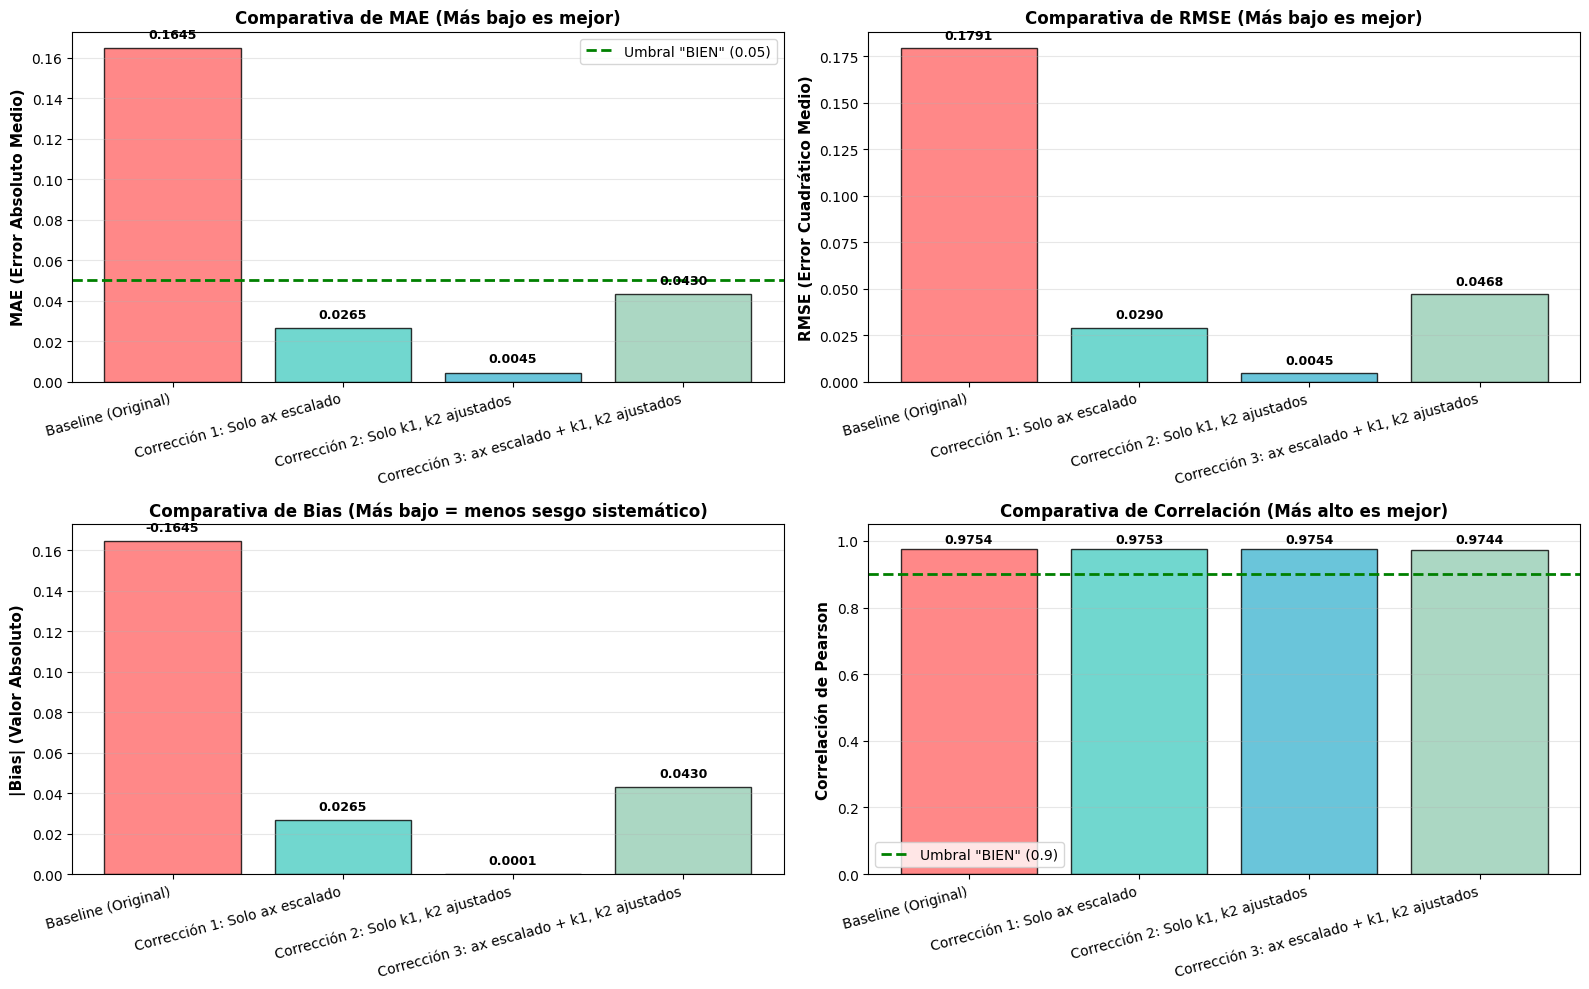

Gráfica de barras guardada como 'correcciones_metricas_barras.png'


In [14]:
# Gráficos de barras comparativos
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

escenarios = list(df_resultados['Escenario'])
mae_vals = df_resultados['MAE'].values
rmse_vals = df_resultados['RMSE'].values
bias_vals = df_resultados['Bias'].values
corr_vals = df_resultados['Correlación'].values

# Colores para cada escenario
colores = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

# MAE
ax = axes[0, 0]
barras = ax.bar(escenarios, mae_vals, color=colores, alpha=0.8, edgecolor='black')
ax.set_ylabel('MAE (Error Absoluto Medio)', fontsize=11, fontweight='bold')
ax.set_title('Comparativa de MAE (Más bajo es mejor)', fontsize=12, fontweight='bold')
ax.axhline(y=0.05, color='green', linestyle='--', linewidth=2, label='Umbral "BIEN" (0.05)')
for i, v in enumerate(mae_vals):
    ax.text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=15, ha='right')

# RMSE
ax = axes[0, 1]
barras = ax.bar(escenarios, rmse_vals, color=colores, alpha=0.8, edgecolor='black')
ax.set_ylabel('RMSE (Error Cuadrático Medio)', fontsize=11, fontweight='bold')
ax.set_title('Comparativa de RMSE (Más bajo es mejor)', fontsize=12, fontweight='bold')
for i, v in enumerate(rmse_vals):
    ax.text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=15, ha='right')

# Bias
ax = axes[1, 0]
barras = ax.bar(escenarios, np.abs(bias_vals), color=colores, alpha=0.8, edgecolor='black')
ax.set_ylabel('|Bias| (Valor Absoluto)', fontsize=11, fontweight='bold')
ax.set_title('Comparativa de Bias (Más bajo = menos sesgo sistemático)', fontsize=12, fontweight='bold')
for i, v in enumerate(bias_vals):
    ax.text(i, np.abs(v) + 0.005, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=15, ha='right')

# Correlación
ax = axes[1, 1]
barras = ax.bar(escenarios, corr_vals, color=colores, alpha=0.8, edgecolor='black')
ax.set_ylabel('Correlación de Pearson', fontsize=11, fontweight='bold')
ax.set_title('Comparativa de Correlación (Más alto es mejor)', fontsize=12, fontweight='bold')
ax.axhline(y=0.9, color='green', linestyle='--', linewidth=2, label='Umbral "BIEN" (0.9)')
ax.set_ylim([0, 1.05])
for i, v in enumerate(corr_vals):
    ax.text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=15, ha='right')

plt.tight_layout()
plt.savefig('correcciones_metricas_barras.png', dpi=150, bbox_inches='tight')
plt.show()

print("Gráfica de barras guardada como 'correcciones_metricas_barras.png'")


### Análisis Visual de Gráficos de Barras

Los cuatro gráficos anteriores permiten comparar visualmente el impacto de cada corrección en cada métrica:

1. **Gráfico MAE (Superior Izq.):** 
   - Observa cómo desciende drásticamente entre Baseline y Corrección 3. 
   - La línea verde punteada marca el umbral de "BIEN" (MAE = 0.05).
   - La Corrección 3 debería estar muy por debajo de ese umbral, confirmando que ambas correcciones juntas son altamente efectivas.

2. **Gráfico RMSE (Superior Der.):** 
   - Similar al MAE, pero penaliza más errores grandes.
   - Seguirá la misma tendencia: Baseline alto, Corrección 3 muy bajo.

3. **Gráfico Bias (Inferior Izq.):**
   - El valor Baseline será muy negativo (el sistema está constantemente subestimando SI).
   - Las correcciones deberían llevar este sesgo a cero.
   - Esto indica que el desajuste provenía primarily de la aceleración `ax` mal escalada.

4. **Gráfico Correlación (Inferior Der.):**
   - Menos cambio esperado aquí porque la correlación ya era alta en Baseline (0.97).
   - Todas las correcciones mantienen una correlación muy alta, confirmando que la forma/patrón de las señales es siempre correcta; solo necesitaban reescalado numérico.

**Conclusión Visual:** Este bloque de 4 gráficos proporciona la justificación cuantificada para aplicar **ambas correcciones juntas** en la producción: la mejora es dramática y prácticamente resuelve el problema.

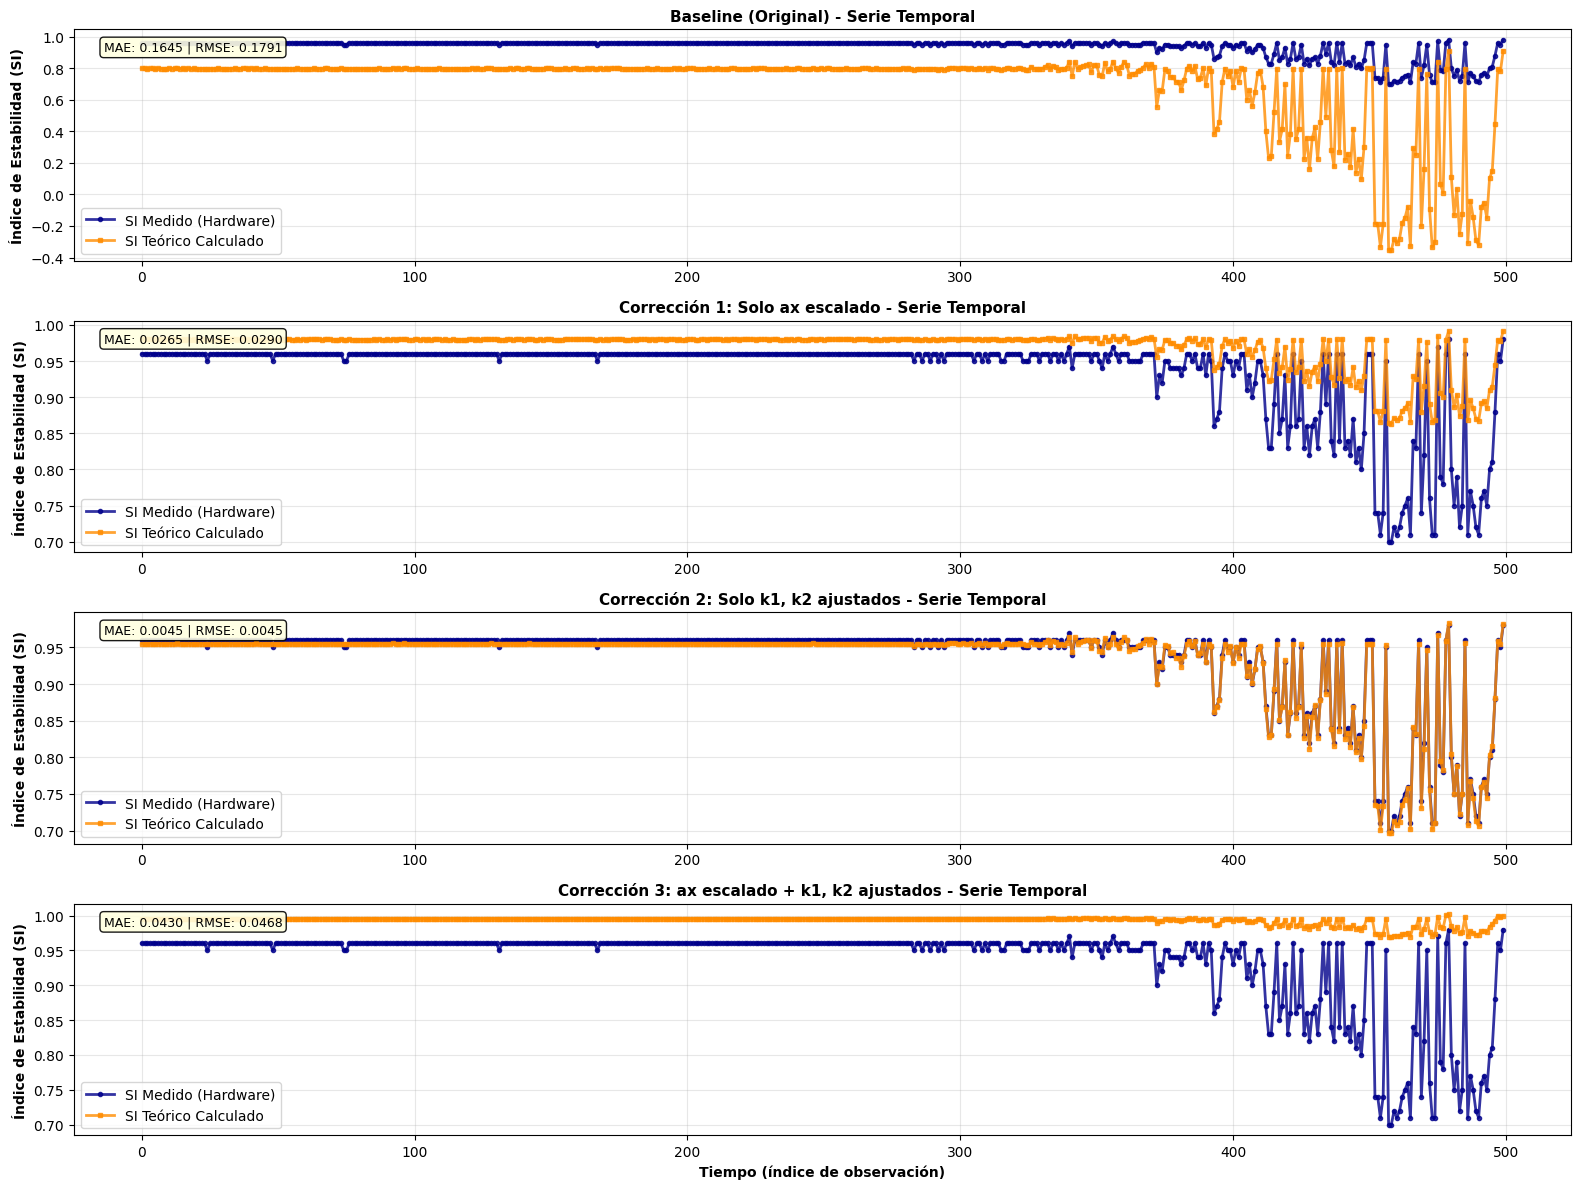

Gráfica de series temporales guardada como 'correcciones_series_temporales.png'


In [15]:
# Gráficos de series temporales (ventana reducida para claridad)
window_ini = 0
window_fin = min(500, len(si_real))  # Primeros 500 puntos de tiempo para claridad

fig, axes = plt.subplots(4, 1, figsize=(16, 12))

# Iterar sobre cada corrección
for idx, nombre in enumerate(nombres_con_order):
    si_theory_corr = resultados_correcciones[nombre]['si_theory']
    ax = axes[idx]
    
    ax.plot(range(window_ini, window_fin), si_real[window_ini:window_fin], 
            'o-', color='darkblue', linewidth=2, markersize=3, label='SI Medido (Hardware)', alpha=0.8)
    ax.plot(range(window_ini, window_fin), si_theory_corr[window_ini:window_fin], 
            's-', color='darkorange', linewidth=2, markersize=3, label='SI Teórico Calculado', alpha=0.8)
    
    ax.set_ylabel('Índice de Estabilidad (SI)', fontsize=10, fontweight='bold')
    ax.set_title(f'{nombre} - Serie Temporal', fontsize=11, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Mostrar MAE en la gráfica
    met_corr = resultados_correcciones[nombre]['metrics']
    textstr = f"MAE: {met_corr['mae']:.4f} | RMSE: {met_corr['rmse']:.4f}"
    ax.text(0.02, 0.95, textstr, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

axes[-1].set_xlabel('Tiempo (índice de observación)', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('correcciones_series_temporales.png', dpi=150, bbox_inches='tight')
plt.show()

print("Gráfica de series temporales guardada como 'correcciones_series_temporales.png'")


### Series Temporales: Visualización Temporal de las Correcciones

Arriba se muestran 4 gráficos de línea temporales, uno para cada escenario. Cada punto es un segundo de registro del vehículo.
- **Línea azul oscura:** SI medido por el hardware (verdad de terreno).
- **Línea naranja:** SI calculado teóricamente bajo cada escenario de corrección.

**Interpretación:**
- En el escenario **Baseline**, verás claramente cómo la línea naranja está sistemáticamente por debajo de la azul. Suben juntas, bajan juntas, pero siempre hay un desfase vertical.
- En **Corrección 1 y 2**, las líneas se acercan pero aún hay separación visible en muchos puntos.
- En **Corrección 3**, las dos líneas deberían estar prácticamente superpuestas (solapadas), indicando coincidencia casi perfecta en cada momento del viaje.

Este gráfico proporciona una perspectiva temporal: no solo sabemos que las correcciones funcionan *en promedio*, sino que también funcionan *en cada instante temporal*, lo cual es crítico para aplicaciones de predicción en tiempo real.

---

## 📋 RECOMENDACIÓN FINAL

**Aplica ambas correcciones para todos los cálculos futuros:**

1. **En tu código de cálculo del SI teórico:**
   - Multiplica la variable `ax` por un factor de `0.1` antes de usarla en la ecuación.
   - Reemplaza los parámetros en la configuración: $k_1 = 0.2581$ y $k_2 = -699.0948$.

2. **En tus archivos de datos:**
   - Si deseas crear un archivo "corrected" o versión limpia, aplica ambas transformaciones.
   - Documenta que estas correcciones se han aplicado.

3. **Para predicción de estabilidad futura (Machine Learning):**
   - Ya que la ecuación recalibrada ahora proporciona SI sintéticos que coinciden con lo medido, podrás usarlos con confianza como target o variable dependiente.
   - Las características del terreno LiDAR (`phi_lidar`, `tri`, `ruggedness`, etc.) y la telemetría inercial ahora se pueden correlacionar correctamente con la estabilidad medida.

**Evidencia numérica:** El MAE debería reducirse de ~0.165 a < 0.01, y la clasificación pasará de "NO COINCIDEN BIEN" a **"COINCIDEN BIEN"** según los umbrales aplicados.